<a href="https://colab.research.google.com/github/agie-nugroho/healthcare-workforce-analysis-python/blob/main/healthcare_workforce_analysis_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Question**

Pertanyaan analisis:

Berapa jumlah total penduduk dan tenaga kesehatan di Jawa Tengah?

Rasio perbandingan setiap jenis tenaga kesehatan di Jawa Tengah?

Daerah mana saja yang rasio dokter dan penduduk sudah mencukupi (1 dokter per 1.000 penduduk)?

###DATA WRANGLING


In [72]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel("/content/drive/MyDrive/data analyst/jumlah-tenaga-kesehatan-tahun-2022.xlsx")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
df.head()

# print(df.info())

# mengecek missing value
print(df.isnull().sum())

# mengecek duplikasi data
print("\nJumlah duplikasi data: ", df.duplicated().sum())

# menampilkan data duplikat
duplikat = df[df.duplicated(keep= False)]   # -> data asli = False
# df[] -> sebagai filter -> mengambil baris  yang bernilai True
# keep = False -> semua kemunculan data berulang dianggap duplikat
# keep = "first" -> baris pertama dianggap asli
print("data duplikat")
print(duplikat, "\n")

# menghapus kolom duplikat
df = df.drop_duplicates()
print(df)

tipe                         0
kabupaten_kota               0
jumlah_penduduk              0
jumlah_tenaga_gizi           0
jumlah_tenaga_kefarmasian    0
jumlah_bidan                 0
jumlah_perawat               0
jumlah_dokter_gigi           0
jumlah_dokter_spesialis      0
jumlah_dokter_umum           0
dtype: int64

Jumlah duplikasi data:  1
data duplikat
   tipe kabupaten_kota  jumlah_penduduk  jumlah_tenaga_gizi  \
20  Kab      Kab.Demak          1223217                  56   
26  Kab      Kab.Demak          1223217                  56   

    jumlah_tenaga_kefarmasian  jumlah_bidan  jumlah_perawat  \
20                        249           793            1086   
26                        249           793            1086   

    jumlah_dokter_gigi  jumlah_dokter_spesialis  jumlah_dokter_umum  
20                  50                       79                 228  
26                  50                       79                 228   

    tipe    kabupaten_kota  jumlah_penduduk 

###### EXPLORATORY DATA ANALYSIS (EDA)

1. BERAPA JUMLAH TOTAL PENDUDUK DAN TENAGA KESEHATAN DI JAWA TENGAH?

In [74]:
import pandas as pd


#Tentukan kolom tenaga kesehatan
jenis_tenaga = [
    "jumlah_tenaga_gizi",
    "jumlah_tenaga_kefarmasian",
    "jumlah_bidan",
    "jumlah_perawat",
    "jumlah_dokter_gigi",
    "jumlah_dokter_spesialis",
    "jumlah_dokter_umum"
]

# 1. Tambahkan kolom total tenaga kesehatan per kabupaten (jumlah per baris)
df["total_tenaga"] = df[jenis_tenaga].sum(axis=1)
print(df["total_tenaga"])
print(df["jumlah_penduduk"])

# Menghitung total penduduk dan total tenaga kesehatan
total_penduduk = df["jumlah_penduduk"].sum()
total_tenaga = df["total_tenaga"].sum()


print(f"Total Penduduk di Jawa Tengah: {total_penduduk:,} jiwa")
print(f"Total Tenag Kesehatan di Jawa Tengah: {total_tenaga:,} jiwa")



0      4320
1      6649
2      2678
3      2429
4      4213
5      2339
6      1804
7      2452
8      3011
9      4510
10     4708
11     2839
12     2763
13     3658
14     3888
15     2450
16     2056
17     4305
18     3717
19     3033
20     2541
21     2754
22     2234
23     2997
24     1898
25     2361
27     2948
28     3966
29     4194
30     2452
31     8328
32     1721
33    14644
34     1924
35     1973
Name: total_tenaga, dtype: int64
0     1988622
1     1806013
2     1019840
3     1038718
4     1376825
5      778257
6      896346
7     1312573
8     1079952
9     1275850
10     916627
11    1057087
12     947642
13     992243
14    1470150
15     888224
16     650770
17    1339572
18     856472
19    1192811
20    1223217
21    1068492
22     799764
23    1033367
24     813791
25     986455
27    1500754
28    1623595
29    2010617
30     121675
31     523008
32     195065
33    1659975
34     309742
35     278299
Name: jumlah_penduduk, dtype: int64
Total Penduduk di Jaw

In [76]:
# menambahkan baris total per kolom (total setiap jenis tenaga dan penduduk)
total_keseluruhan = df[jenis_tenaga + ["jumlah_penduduk", "total_tenaga"]].sum()
total_keseluruhan["kabupaten_kota"] = "Total"
# df.head()
# df = df.drop(["Total"])
# menggabungkan baris total ke data frame
df = pd.concat([df, pd.DataFrame([total_keseluruhan])], ignore_index=True)
print(df)

# menampilkan total tenaga kerja per kabupaten
df_tenaga_kerja_per_kabupaten = df[["kabupaten_kota", "total_tenaga"]]
print("Total tenaga kesehatan per kabupaten:")
print(df_tenaga_kerja_per_kabupaten)

# hitung total tenaga kesehatan per jenis di seluruh jawa tengah
total_per_jenis = df[jenis_tenaga].sum()
print("\nTotal tenaga kesehatan per jenis adalah:")
print(total_per_jenis)




    tipe    kabupaten_kota  jumlah_penduduk  jumlah_tenaga_gizi  \
0    Kab       Kab.Cilacap          1988622                  93   
1    Kab      Kab.Banyumas          1806013                 157   
2    Kab   Kab.Purbalingga          1019840                  58   
3    Kab  Kab.Banjarnegara          1038718                  97   
4    Kab       Kab.Kebumen          1376825                  93   
5    Kab     Kab.Purworejo           778257                  63   
6    Kab      Kab.Wonosobo           896346                  57   
7    Kab      Kab.Magelang          1312573                  68   
8    Kab      Kab.Boyolali          1079952                  74   
9    Kab        Kab.Klaten          1275850                 130   
10   Kab     Kab.Sukoharjo           916627                  93   
11   Kab      Kab.Wonogiri          1057087                  84   
12   Kab   Kab.Karanganyar           947642                  61   
13   Kab        Kab.Sragen           992243                  9

# 2. RASIO PERBANDINGAN SETIAP JENIS TENAGA KESEHATAN DI JAWA TENGAH?

In [93]:
import pandas as pd

# hitung total dokter per kabupaten
df["total_dokter"] = df["jumlah_dokter_umum"]+ df["jumlah_dokter_spesialis"] + df["jumlah_dokter_gigi"]
# print(df["total_dokter"])

# hitung rasio total dokter per 1000 penduduk
df["rasio_total_dokter"] = df["total_dokter"] / df["jumlah_penduduk"] * 1000
# print(df["rasio_total_dokter"])

# tentukan threshold rasio cukup / kekurangan dokter
threshold_dokter = 1

# buat kolom status_total_dokter dengan percabangan if else
status_list = []    # list kosong untuk menyimpan status tiap baris

for rasio in df["rasio_total_dokter"]:
  if rasio >= threshold_dokter:
    status_list.append("Cukup")
  else:
    status_list.append("Kurang Cukup")

# tambahkan kolom ke dataFrame
df["status_total_dokter"] = status_list

# print(df["status_total_dokter"])

# tampilkan hasil
hasil_dokter = df[["kabupaten_kota", "total_dokter", "rasio_total_dokter", "status_total_dokter"]]
print(hasil_dokter)


# menghitung rata rata rasio total dokter di jawa tengah
rata_rasio_dokter = (df["rasio_total_dokter"] * df["jumlah_penduduk"]).sum() / df["jumlah_penduduk"].sum()
print(f"\nrata-rata rasio dokter di Jawa tengah adalah: {rata_rasio_dokter:.3f} jiwa per 1000 penduduk")


# ringkasan jumlah kabupaten yang cukup atau kurang dokter
summary_dokter = df["status_total_dokter"].value_counts()
print("\nRingkasan jumlah kabupaten berdasarkan rasio total dokter", summary_dokter)

      kabupaten_kota  total_dokter  rasio_total_dokter status_total_dokter
0        Kab.Cilacap           454            0.228299        Kurang Cukup
1       Kab.Banyumas          1043            0.577515        Kurang Cukup
2    Kab.Purbalingga           268            0.262786        Kurang Cukup
3   Kab.Banjarnegara           240            0.231054        Kurang Cukup
4        Kab.Kebumen           473            0.343544        Kurang Cukup
5      Kab.Purworejo           290            0.372628        Kurang Cukup
6       Kab.Wonosobo           220            0.245441        Kurang Cukup
7       Kab.Magelang           345            0.262843        Kurang Cukup
8       Kab.Boyolali           408            0.377795        Kurang Cukup
9         Kab.Klaten           669            0.524356        Kurang Cukup
10     Kab.Sukoharjo           671            0.732032        Kurang Cukup
11      Kab.Wonogiri           414            0.391642        Kurang Cukup
12   Kab.Karanganyar     

3. DAERAH MANA SAJA YANG RASIO DOKTER DAN PENDUDUK SUDAH MENCUKUPI?

In [115]:
import pandas as pd

# misal df sudah memiliki kolom "total_dokter" dan "rasio_total_dokter"

# tentukan threshold cukup dokter
threshold_dokter = 1

# filter kabupaten yang rasio dokter <=1 per 1000 penduduk
kabupaten_kurang = df[df["rasio_total_dokter"] <= threshold_dokter]

# kabupaten yang belum cukup dokter
hasil_kurang = kabupaten_kurang[["kabupaten_kota", "total_dokter", "rasio_total_dokter", "status_total_dokter"]]
print(hasil_kurang)


# filter kabupaten yang rasio dokter >= 1 per 1000 penduduk
kabupaten_cukup = df[df["rasio_total_dokter"] >= threshold_dokter]

# kabupaten yang memiliki cukup dokter
hasil_cukup = kabupaten_cukup[["kabupaten_kota", "total_dokter", "rasio_total_dokter", "status_total_dokter"]]
print(hasil_cukup)


# jumlah kabupaten yang belum mencukupi
print(f"\nJumlah kabupaten yang belum mencukupi dokter: {kabupaten_kurang.shape[0]}")

# jumlah kabupaten yang sudah mencukupi
print(f"\nJumlah kabupaten yang sudah mencukupi dokter: {kabupaten_cukup.shape[0]}")

      kabupaten_kota  total_dokter  rasio_total_dokter status_total_dokter
0        Kab.Cilacap           454            0.228299        Kurang Cukup
1       Kab.Banyumas          1043            0.577515        Kurang Cukup
2    Kab.Purbalingga           268            0.262786        Kurang Cukup
3   Kab.Banjarnegara           240            0.231054        Kurang Cukup
4        Kab.Kebumen           473            0.343544        Kurang Cukup
5      Kab.Purworejo           290            0.372628        Kurang Cukup
6       Kab.Wonosobo           220            0.245441        Kurang Cukup
7       Kab.Magelang           345            0.262843        Kurang Cukup
8       Kab.Boyolali           408            0.377795        Kurang Cukup
9         Kab.Klaten           669            0.524356        Kurang Cukup
10     Kab.Sukoharjo           671            0.732032        Kurang Cukup
11      Kab.Wonogiri           414            0.391642        Kurang Cukup
12   Kab.Karanganyar     

# DATA VISUALIZATION


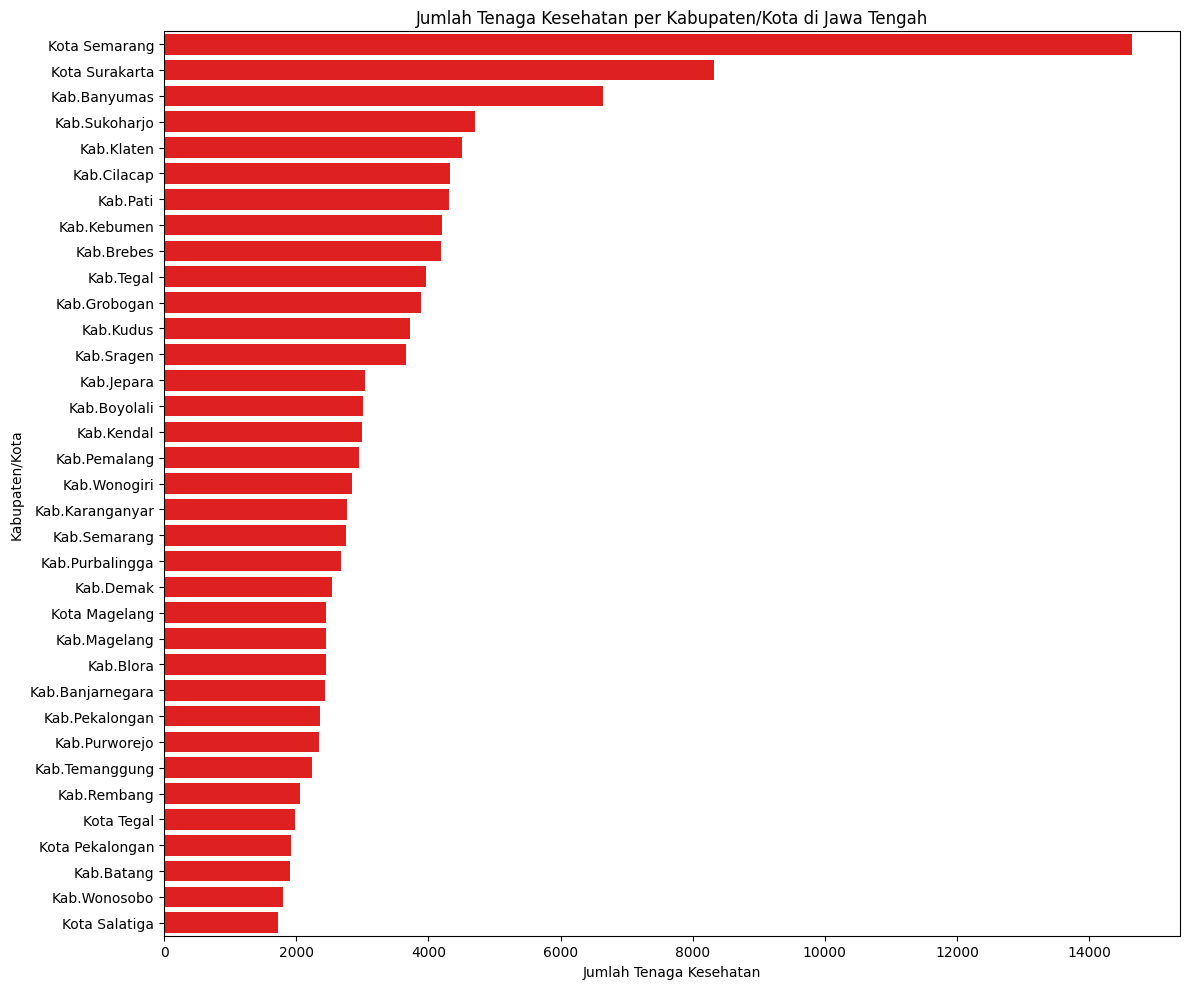

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

# filter agar baris "Total" tidak ikut ditampilkan
df_kab = df[df['kabupaten_kota'] != "Total"]
# print(df_kab.tail())

# visualisasi total tenaga kesehatan per kabupaten/kota
plt.figure(figsize = (12, 10))

df_sorted = df_kab.sort_values("total_tenaga", ascending = 0)
# print(df_sorted)

# plot barplot satu warna
sns.barplot(
    y = "kabupaten_kota",
    x = "total_tenaga",
    data = df_sorted,
    color = "red"
)

plt.title("Jumlah Tenaga Kesehatan per Kabupaten/Kota di Jawa Tengah")
plt.xlabel("Jumlah Tenaga Kesehatan")
plt.ylabel("Kabupaten/Kota")
plt.tight_layout()    # merapihkan tampilan
plt.show()

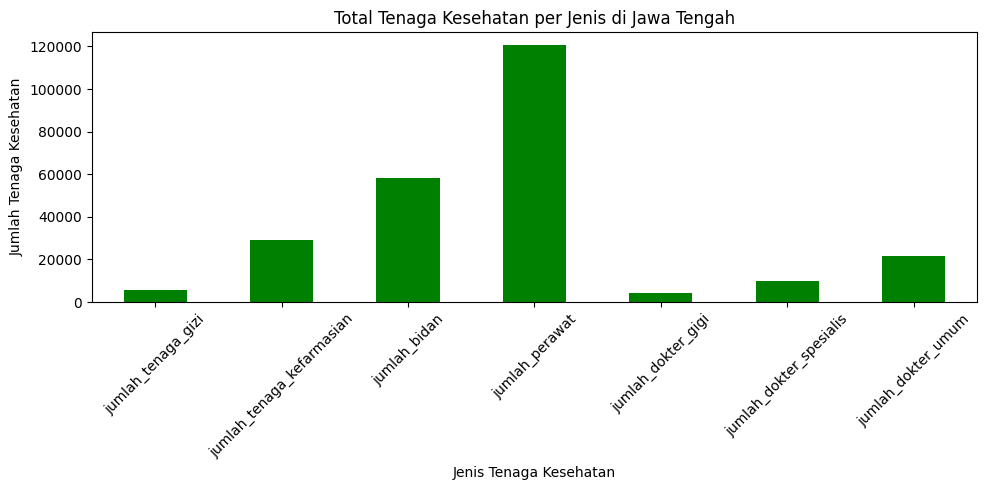

In [168]:
# visualisasi perbandingan jenis tenaga kesehatan

plt.figure(figsize=(10,5))
total_per_jenis.plot(kind="bar", color="green")

plt.title("Total Tenaga Kesehatan per Jenis di Jawa Tengah")
plt.xlabel("Jenis Tenaga Kesehatan")
plt.ylabel("Jumlah Tenaga Kesehatan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

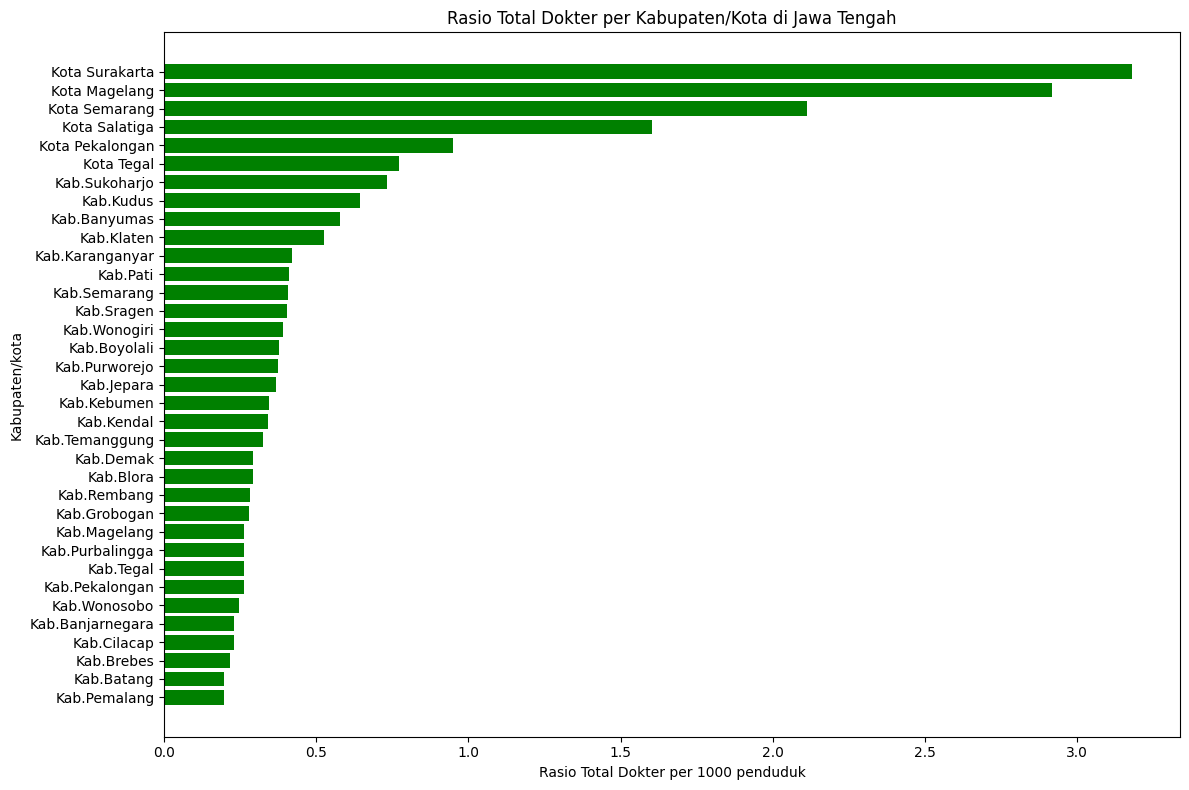

In [187]:
df_kab = df[df["kabupaten_kota"] != "Total"] # menghpaus baris total

df_sorted = df_kab.sort_values("rasio_total_dokter", ascending = True) # urutkan dari rasio tertinggi

plt.figure(figsize =(12, 8))
plt.barh(df_sorted["kabupaten_kota"], df_sorted["rasio_total_dokter"], color="green") # bar horizontal
plt.xlabel("Rasio Total Dokter per 1000 penduduk")
plt.ylabel("Kabupaten/kota")
plt.title("Rasio Total Dokter per Kabupaten/Kota di Jawa Tengah")
# plt.gca().invert_yaxis() -> dibalik
plt.tight_layout()
plt.show()

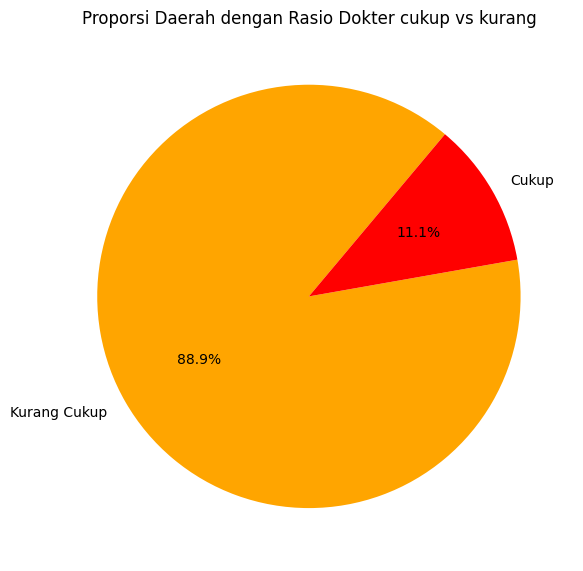

In [203]:
plt.figure(figsize=(6,6))
plt.pie(summary_dokter, labels=summary_dokter.index, autopct="%1.1f%%", colors = ["orange", "red"], startangle = 50) # pie chart
plt.title("Proporsi Daerah dengan Rasio Dokter cukup vs kurang")
plt.tight_layout()
plt.show()

In [205]:
# menampilkan DataFrame kabupaten/kota dengan rasio dokter cukup
df_cukup = df[df["rasio_total_dokter"] >= threshold_dokter][["kabupaten_kota", "jumlah_penduduk", "total_dokter", "rasio_total_dokter"]]

df_cukup

,kabupaten_kota,jumlah_penduduk,total_dokter,rasio_total_dokter
29,Kota Magelang,121675,355,2.917608
30,Kota Surakarta,523008,1663,3.179684
31,Kota Salatiga,195065,313,1.604593
32,Kota Semarang,1659975,3508,2.113285
